<a href="https://colab.research.google.com/github/abdmomin/llms4ess-project/blob/main/Prepare_Dataset_for_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10000 Restaurant Reviews Dataset

In [ ]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("joebeachcapital/restaurant-reviews")

print("Path to dataset files:", path)

100%|██████████| 1.23M/1.23M [00:00<00:00, 31.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/joebeachcapital/restaurant-reviews/versions/1


In [ ]:
import os

os.listdir(path)

['Restaurant reviews.csv']

In [ ]:
df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))
df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN


In [ ]:
df.shape

(10000, 8)

In [ ]:
df = df.drop(columns=['7514', 'Pictures'], axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
dtypes: object(6)
memory usage: 468.9+ KB


In [ ]:
df.isna().sum()

,0
Restaurant,0
Reviewer,38
Review,45
Rating,38
Metadata,38
Time,38


In [ ]:
df = df.dropna(subset=['Review', 'Reviewer', 'Rating'])

In [ ]:
df.isna().sum()

,0
Restaurant,0
Reviewer,0
Review,0
Rating,0
Metadata,0
Time,0


In [ ]:
df['Rating'].unique()

array(['5', '4', '1', '3', '2', '3.5', '4.5', '2.5', '1.5', 'Like'],
      dtype=object)

In [ ]:
df = df[df['Rating'] != 'Like']

In [ ]:
df['Rating'] = df['Rating'].astype(float).astype(int)

In [ ]:
df = df[df['Rating'].between(1, 5)]

In [ ]:
df['Rating'].unique()

array([5, 4, 1, 3, 2])

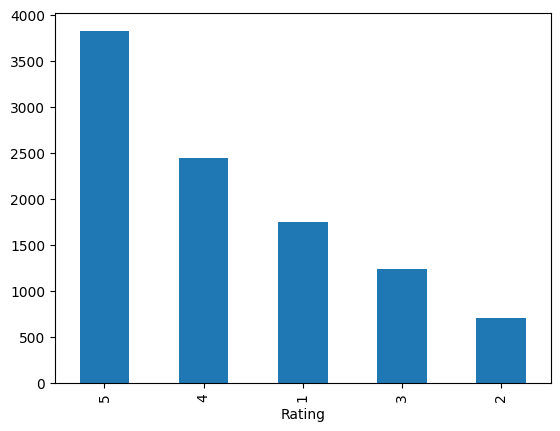

In [ ]:
df.Rating.value_counts().plot(kind='bar');

In [ ]:
import re

def clean_text(t):
  t = str(t).lower()
  t = re.sub(r'<.*?>', '', t)   # remove HTML tags
  t = re.sub(r'[^a-z0-9\s]', '', t)  # keep alphanumeric
  t = re.sub(r'\s+', ' ', t).strip()
  return t

In [ ]:
df['Review'] = df['Review'].apply(clean_text)

In [ ]:
df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time
0,Beyond Flavours,Rusha Chakraborty,the ambience was good food was quite good had ...,5,"1 Review , 2 Followers",5/25/2019 15:54
1,Beyond Flavours,Anusha Tirumalaneedi,ambience is too good for a pleasant evening se...,5,"3 Reviews , 2 Followers",5/25/2019 14:20
2,Beyond Flavours,Ashok Shekhawat,a must try great food great ambience thnx for ...,5,"2 Reviews , 3 Followers",5/24/2019 22:54
3,Beyond Flavours,Swapnil Sarkar,soumen das and arun was a great guy only becau...,5,"1 Review , 1 Follower",5/24/2019 22:11
4,Beyond Flavours,Dileep,food is goodwe ordered kodi drumsticks and bas...,5,"3 Reviews , 2 Followers",5/24/2019 21:37


## Finding potential AI content

In [ ]:
# Convert to datetime if available
df['Time'] = pd.to_datetime(df['Time'], errors='coerce')

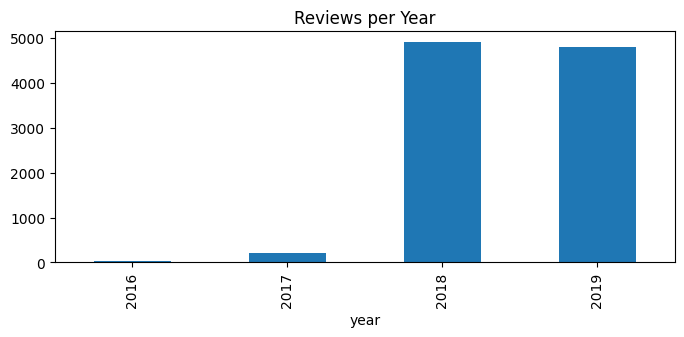

In [ ]:
import matplotlib.pyplot as plt

# review count by year
df['year'] = df['Time'].dt.year
df['year'].value_counts().sort_index().plot(kind='bar', figsize=(8, 3))
plt.title("Reviews per Year")
plt.show()

In [ ]:
# find clusters of identical or near-identical reviews (possible AI)
dup_reviews = df['Review'].value_counts()
suspicious = dup_reviews[dup_reviews > 3]
print("Potentially synthetic patterns:", len(suspicious))

Potentially synthetic patterns: 36


In [ ]:
df['length'] = df['Review'].str.len()
df['word_count'] = df['Review'].str.split().apply(len)
print(df[['length','word_count']].describe())

            length   word_count
count  9954.000000  9954.000000
mean    269.913301    49.544907
std     327.039749    60.033127
min       0.000000     0.000000
25%     139.000000    24.000000
50%     182.000000    34.000000
75%     310.000000    57.000000
max    5088.000000   955.000000


In [ ]:
# find overly long / short extremes
df['suspicious_len'] = (df['word_count'] < 5) | (df['word_count'] > 500)

# find duplicate reviews per restaurant
dup_mask = df.duplicated(subset=['Review','Restaurant'], keep=False)
df['suspicious_dup'] = dup_mask

# Combine
df['possible_ai'] = df['suspicious_len'] | df['suspicious_dup']
print(df['possible_ai'].mean())

0.13050030138637733


In [ ]:
# filter rows flagged as possibly AI-generated
suspect_reviews = df[df['possible_ai'] == 1]

print(f"Total possible AI-generated reviews: {len(suspect_reviews)}")

Total possible AI-generated reviews: 1299


In [ ]:
df.columns = df.columns.str.lower()

In [ ]:
suspect_reviews[['Restaurant', 'Review', 'Rating']].sample(20)

,Restaurant,Review,Rating
8940,Mohammedia Shawarma,not as expected,3
3792,Kritunga Restaurant,good,5
2994,Hunger Maggi Point,the worst ever,1
7444,Faasos,food was good,4
2130,Jonathan's Kitchen - Holiday Inn Express & Suites,a peaceful n quite place is something u want a...,4
9891,Triptify,food was awesome,5
6215,Shree Santosh Dhaba Family Restaurant,very poor quality,1
8830,Domino's Pizza,,4
3576,Green Bawarchi Restaurant,gd,4
4883,Udipi's Upahar,delivered on time,5


In [ ]:
# removing 13% possible ai reviews
df = df[df['possible_ai'] == 0].copy()

In [ ]:
print(f"Oldest date: {df['time'].min()}")
print(f"Latest date: {df['time'].max()}")

Oldest date: 2016-05-31 16:41:00
Latest date: 2019-05-25 20:23:00


## Metadata Extraction

In [ ]:
df.restaurant.nunique()

100

In [ ]:
# Clean up restaurant names
df['restaurant_name'] = df['restaurant'].str.strip()
df['rating_value'] = df['rating']

## Assign category (e.g., cuisine or type)

In [ ]:
cuisine_keywords = {
    "Italian": ["pizza", "pasta", "italian"],
    "Mexican": ["mexican", "taco", "burrito"],
    "Chinese": ["chinese", "noodle", "dim sum"],
    "Indian": ["indian", "curry", "biryani", "tandoori"],
    "Japanese": ["japanese", "sushi", "ramen"],
    "Thai": ["thai", "pad thai"],
    "Seafood": ["seafood", "fish", "crab", "lobster"],
    "Steakhouse": ["steak", "grill", "barbecue"],
    "Cafe": ["cafe", "coffee", "espresso"],
    "Dessert": ["dessert", "bakery", "cake", "ice cream"],
    "Bar": ["bar", "pub", "brewery"]
}

def infer_category(row):
    text = f"{row['restaurant_name']} {row['review']}".lower()
    for category, keywords in cuisine_keywords.items():
        if any(kw in text for kw in keywords):
            return category
    return "General"

df['category'] = df.apply(infer_category, axis=1)

In [ ]:
df.category.value_counts()

,count
category,
General,4265
Indian,1325
Italian,595
Bar,513
Dessert,501
Steakhouse,421
Chinese,417
Cafe,301
Seafood,239


## Extract descriptive keywords

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

reviews = df['review']

vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = vectorizer.fit_transform(reviews)

# Get top 3 keywords per review
feature_names = vectorizer.get_feature_names_out()

def top_keywords(row_idx):
    row = tfidf_matrix[row_idx].toarray().flatten()
    top_indices = row.argsort()[-3:][::-1]
    return [feature_names[i] for i in top_indices]

df['keywords'] = [top_keywords(i) for i in range(len(df))]

In [ ]:
df[['restaurant_name', 'rating_value', 'category', 'keywords']].sample(10)

,restaurant_name,rating_value,category,keywords
2526,Tiki Shack,4,Italian,"[didnt, terrace, weekday]"
9992,Chinese Pavilion,5,Chinese,"[ive, professional, best]"
2162,Jonathan's Kitchen - Holiday Inn Express & Suites,4,Seafood,"[brunch, sunday, la]"
7751,Squeeze @ The Lime,2,General,"[plastic, 30, packing]"
9685,Hyderabadi Daawat,5,Dessert,"[murgh, having, desserts]"
7868,Khaan Saab,5,General,"[royal, prawn, superb]"
5683,Feast - Sheraton Hyderabad Hotel,5,General,"[choco, nice, attentive]"
9222,Collage - Hyatt Hyderabad Gachibowli,2,Indian,"[little, asked, took]"
5618,Feast - Sheraton Hyderabad Hotel,5,Dessert,"[curd, real, looked]"
4273,Karachi Cafe,5,Italian,"[karachi, theme, placed]"


In [ ]:
if not os.path.exists("data"):
  os.makedirs("data")

In [ ]:
df.to_csv("data/cleaned_reviews.csv", index=False)

## Create Splits

In [ ]:
from pathlib import Path

ROOT = Path.cwd()
DATA = ROOT / "data"

DATA.mkdir(exist_ok=True)

In [ ]:
from sklearn.model_selection import train_test_split

df_prompt, df_holdout = train_test_split(df, test_size=0.2, stratify=df['rating'], random_state=42)

df_prompt.to_csv(DATA / "prompt_bank.csv", index=False)
df_holdout.to_csv(DATA / "holdout.csv", index=False)

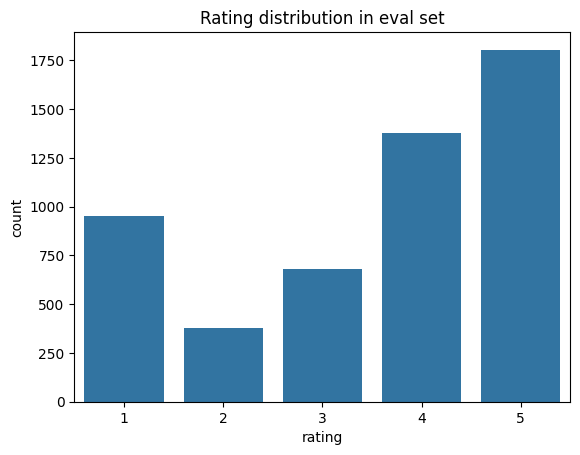

In [ ]:
import seaborn as sns

sns.countplot(x='rating', data=df_prompt)
plt.title("Rating distribution in eval set")
plt.show()